# Data Visualization: Marital Status vs Qualification
**Assignment – Data Science Visualization**  
This notebook visualizes the relationship between **marital status** and **educational qualification** using Matplotlib, Seaborn, and Plotly.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Generate Sample Dataset

In [2]:
qualifications = ['Matric', 'Intermediate', 'Bachelor', 'Master', 'PhD']
marital_statuses = ['Single', 'Married', 'Divorced', 'Widowed']

df = pd.read_csv('marital_status_dataset.csv')
df['Qualification'] = pd.Categorical(df['Qualification'], categories=qualifications, ordered=True)

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (2383, 3)

First 5 rows:


,ID,Qualification,Marital_Status
0,1,Intermediate,Single
1,2,Master,Married
2,3,Master,Married
3,4,Bachelor,Single
4,5,Master,Single


## 3. Basic Data Exploration

In [3]:
print('--- Value Counts: Qualification ---')
print(df['Qualification'].value_counts().sort_index())
print('\n--- Value Counts: Marital Status ---')
print(df['Marital_Status'].value_counts())
print('\n--- Cross Tabulation ---')
crosstab = pd.crosstab(df['Qualification'], df['Marital_Status'])
print(crosstab)

--- Value Counts: Qualification ---
Qualification
Matric          250
Intermediate    420
Bachelor        860
Master          620
PhD             233
Name: count, dtype: int64

--- Value Counts: Marital Status ---
Marital_Status
Married     1124
Single       834
Divorced     265
Widowed      160
Name: count, dtype: int64

--- Cross Tabulation ---
Marital_Status  Divorced  Married  Single  Widowed
Qualification                                     
Matric                32       80     117       21
Intermediate          49      163     172       36
Bachelor              95      393     321       51
Master                58      347     177       38
PhD                   31      141      47       14


## 4. Visualization 1 – Stacked Bar Chart (Matplotlib)

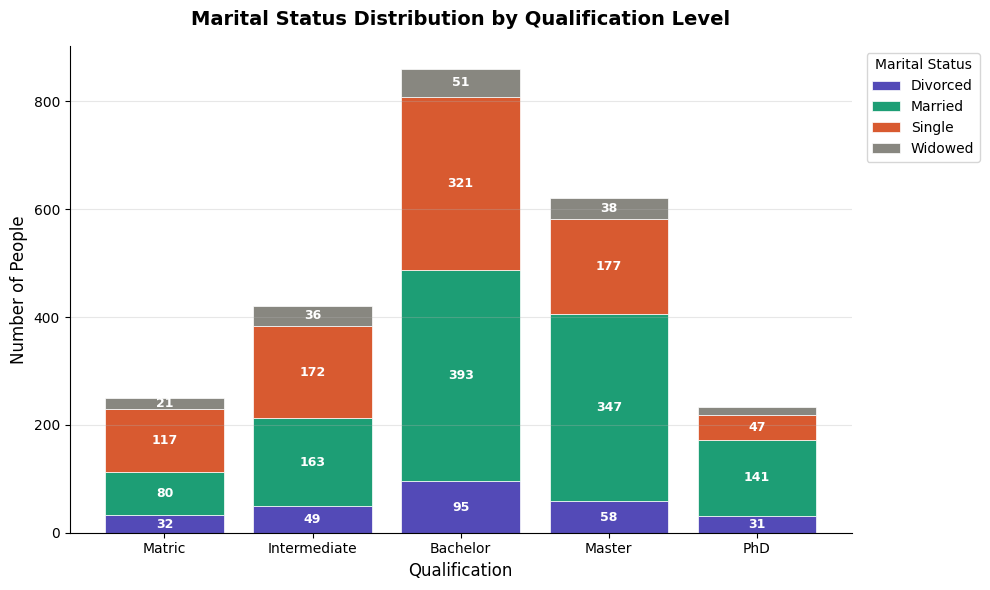

Stacked bar chart saved as stacked_bar_chart.png


In [4]:
crosstab = pd.crosstab(df['Qualification'], df['Marital_Status'])
crosstab = crosstab.reindex(qualifications)

colors = ['#534AB7', '#1D9E75', '#D85A30', '#888780']
statuses = crosstab.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(qualifications))
for i, status in enumerate(statuses):
    bars = ax.bar(qualifications, crosstab[status], bottom=bottom,
                  color=colors[i], label=status, edgecolor='white', linewidth=0.5)
    # Add count labels inside bars
    for bar, val in zip(bars, crosstab[status]):
        if val > 20:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    str(val), ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += crosstab[status].values

ax.set_title('Marital Status Distribution by Qualification Level', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Qualification', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)
ax.legend(title='Marital Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stacked_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Stacked bar chart saved as stacked_bar_chart.png')

## 5. Visualization 2 – Grouped Bar Chart (Seaborn)

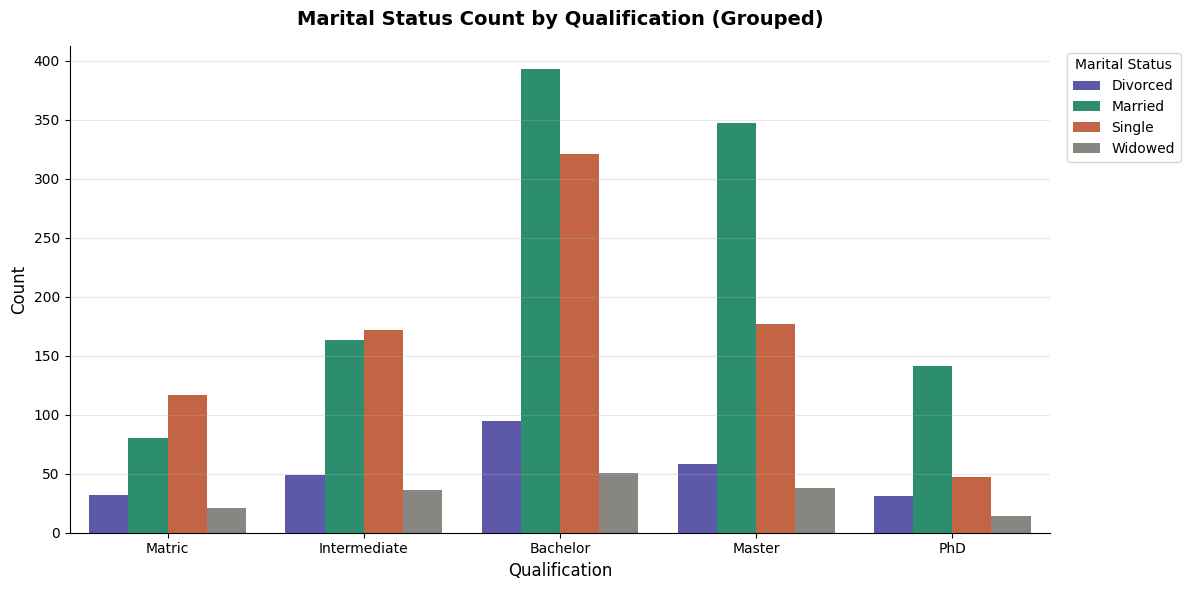

Grouped bar chart saved as grouped_bar_chart.png


In [5]:
count_df = df.groupby(['Qualification', 'Marital_Status']).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=count_df,
    x='Qualification', y='Count', hue='Marital_Status',
    palette=['#534AB7', '#1D9E75', '#D85A30', '#888780'],
    order=qualifications,
    ax=ax
)

ax.set_title('Marital Status Count by Qualification (Grouped)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Qualification', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Marital Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grouped_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grouped bar chart saved as grouped_bar_chart.png')

## 6. Visualization 3 – Heatmap (Seaborn)

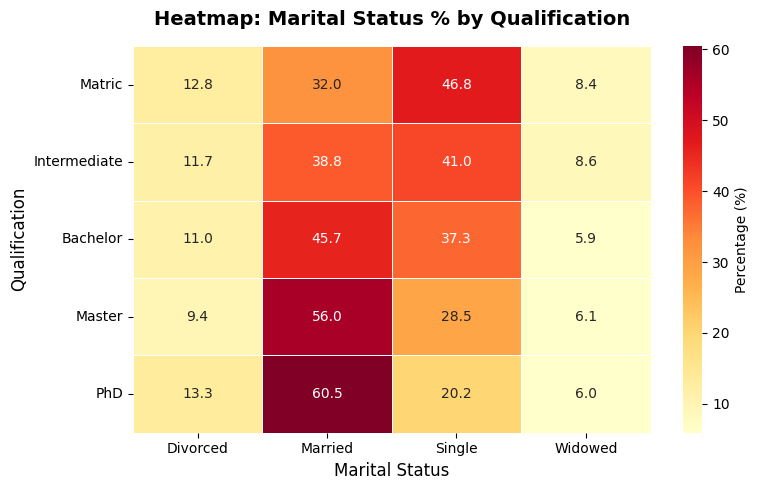

Heatmap saved as heatmap.png


In [6]:
# Normalize crosstab to percentages
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Percentage (%)'}, ax=ax
)

ax.set_title('Heatmap: Marital Status % by Qualification', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Qualification', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as heatmap.png')

## 7. Visualization 4 – Interactive Chart (Plotly)

In [7]:
count_df = df.groupby(['Qualification', 'Marital_Status']).size().reset_index(name='Count')
count_df['Qualification'] = pd.Categorical(count_df['Qualification'], categories=qualifications, ordered=True)
count_df = count_df.sort_values('Qualification')

fig = px.bar(
    count_df,
    x='Qualification', y='Count', color='Marital_Status',
    barmode='stack',
    color_discrete_map={
        'Single': '#534AB7',
        'Married': '#1D9E75',
        'Divorced': '#D85A30',
        'Widowed': '#888780'
    },
    title='Marital Status Distribution by Qualification (Interactive)',
    labels={'Count': 'Number of People', 'Qualification': 'Qualification Level'},
    template='plotly_white'
)

fig.update_layout(
    legend_title_text='Marital Status',
    title_font_size=16,
    bargap=0.2
)

fig.write_html('interactive_chart.html')
fig.show()
print('Interactive chart saved as interactive_chart.html')

Interactive chart saved as interactive_chart.html


## 8. Summary & Observations

In [8]:
print('=== KEY OBSERVATIONS ===')
print()
total = len(df)
for status in marital_statuses:
    count = (df['Marital_Status'] == status).sum()
    print(f'{status:10s}: {count:4d} ({count/total*100:.1f}%)')

print()
print('--- Most common marital status per qualification ---')
for qual in qualifications:
    subset = df[df['Qualification'] == qual]
    most_common = subset['Marital_Status'].value_counts().idxmax()
    print(f'{qual:15s} → {most_common}')

=== KEY OBSERVATIONS ===

Single    :  834 (35.0%)
Married   : 1124 (47.2%)
Divorced  :  265 (11.1%)
Widowed   :  160 (6.7%)

--- Most common marital status per qualification ---
Matric          → Single
Intermediate    → Single
Bachelor        → Married
Master          → Married
PhD             → Married


#### Assignment - 2
##### Apply any ML Algorithm and get Prediction from it 

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("marital_status_dataset.csv")

# Encode Qualification
le_q = LabelEncoder()
X = le_q.fit_transform(df['Qualification']).reshape(-1,1)

# Encode Marital Status
le_y = LabelEncoder()
y = le_y.fit_transform(df['Marital_Status'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.47379454926624737


In [3]:
# Example prediction

new_qualification = "Bachelor"

# Convert to encoded value
new_data = le_q.transform([new_qualification]).reshape(-1, 1)

# Predict
prediction = model.predict(new_data)

# Convert back to original label
predicted_status = le_y.inverse_transform(prediction)

print("Predicted Marital Status:", predicted_status[0])

Predicted Marital Status: Married


In [7]:
qualification = input("Enter Qualification: ")

new_data = le_q.transform([qualification]).reshape(-1, 1)

prediction = model.predict(new_data)

predicted_status = le_y.inverse_transform(prediction)

print("Predicted Marital Status:", predicted_status[0])

Predicted Marital Status: Single
